<div style="text-align: center;"><h1> DaSSA Hackathon Project Code - ClinsightAI</h1>
Filsan Musa, Quynh Nguyen, Lily Holmes</div>

<h3>Introduction</h3>

This dataset contains sentiment-labeled reviews collected from Google Maps for various hospitals in Bengaluru, India. The feedback includes textual reviews from patients and their families, providing insights into their experiences with medical staff, facilities, and overall hospital services.

Data Source: https://www.kaggle.com/datasets/junaid6731/hospital-reviews-dataset

<h3>Install Packages:</h3>

In [ ]:
!pip install nltk

<h3> Import Libraries </h3>

In [ ]:
import pandas as pd
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

<h3> Import Dataset </h3>

In [ ]:
filename = 'hospital.csv'

from google.colab import files
uploaded = files.upload()
df = pd.read_csv(filename)

Saving hospital.csv to hospital.csv


<h3> Data Exploration </h3>

<p>Let's first take a glance at our dataset</p>

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.head()

,Feedback,Sentiment Label,Ratings,Unnamed: 3
0,Good and clean hospital. There is great team o...,1,5,NaN
1,Had a really bad experience during discharge. ...,1,5,NaN
2,I have visited to take my second dose and Proc...,1,4,NaN
3,That person was slightly clueless and offered...,1,3,NaN
4,There is great team of doctors and good OT fac...,0,1,NaN


In [ ]:
df.tail()

,Feedback,Sentiment Label,Ratings,Unnamed: 3
991,very careful about safety measures every one i...,1,4,NaN
992,I do not trust in their reports I got same tes...,0,2,NaN
993,They just want the patients to return to their...,0,1,NaN
994,I suggest you not to visit this hospital if yo...,0,2,NaN
995,NU hospital has provided us the excellent serv...,1,4,NaN


<br>
<p> Looking at the dimensions, and size of our dataset... </p>

In [ ]:
df.shape

(996, 4)

In [ ]:
df.size

3984

In [ ]:
df.dtypes

,0
Feedback,object
Sentiment Label,int64
Ratings,int64
Unnamed: 3,float64


<br>
<p> Now, let's perform a simple analysis before processing the data.</p>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Feedback         996 non-null    object 
 1   Sentiment Label  996 non-null    int64  
 2   Ratings          996 non-null    int64  
 3   Unnamed: 3       0 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 31.3+ KB


<h3>Data Cleaning</h3>

- Check for duplicate rows
- Remove irrelevant columns
- Check for missing values & deal w/ them
- Rename columns
- Normalize text data

<br>
<p> Let's check to see if there are any duplicate values in our dataset, and deal w/ them if necessary.</p>

In [ ]:
#shows total count of duplicate rows (19 rows)
df.duplicated().sum()

np.int64(19)

In [ ]:
#shows the incidents of duplicate rows
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,Feedback,Sentiment Label,Ratings,Unnamed: 3
55,Don't go buy name of the hospital.,0,1,NaN
57,Don't go buy name of the hospital.,0,1,NaN
176,Excellent service. Everything is well taken ca...,1,5,NaN
203,Excellent service. Everything is well taken ca...,1,5,NaN
844,Excellent treatment from hospital Accommodatio...,1,5,NaN
939,Excellent treatment from hospital Accommodatio...,1,5,NaN
423,Found excellent service by Rajeshwari from bil...,1,5,NaN
549,Found excellent service by Rajeshwari from bil...,1,5,NaN
470,Good service by dilip Kumar in helping us fini...,1,5,NaN
539,Good service by dilip Kumar in helping us fini...,1,5,NaN


In [ ]:
#sample case of duplicate rows
df[df["Feedback"].str.contains("Don't go buy name of the hospital.", na=False)]

,Feedback,Sentiment Label,Ratings,Unnamed: 3
55,Don't go buy name of the hospital.,0,1,NaN
57,Don't go buy name of the hospital.,0,1,NaN


In [ ]:
#dropping duplicate rows
df = df.drop_duplicates()

<br>
<p>Next, let's reduce the redundancy by dropping irrelevant columns.</p>

In [ ]:
#dropping since column is empty
df.drop(columns=['Unnamed: 3'], inplace=True)

<br>
<p>Now, let's confirm that there are not missing values in any of our columns.</p>

In [ ]:
#shows number of missing values (nulls) per column
df.isna().sum()

,0
Feedback,0
Sentiment Label,0
Ratings,0


<p>Let's rename some of the existing columns to match naming conventions (we'll use snake_case to name our variables).</p>

In [ ]:
df = df.rename(columns={'Feedback' : 'feedback'
                       ,'Sentiment Label' : 'sentiment_label'
                       ,'Ratings' : 'ratings'})

<p> Finally, let's clean up the text inside our <code>feedback</code> column and store this cleaned data in a new variable <code>cleaned_feedback</code></p>

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

#dictionary of common contraction in english
contractions = {
    "don't": "do not",
    "didn't": "did not",
    "can't": "cannot",
    "won't": "will not",
    "it's": "it is",
    "i'm": "i am",
    "wasn't": "was not",
    "weren't": "were not",
    "isn't": "is not",
    "aren't": "are not",
}

#building a function normalize that cleans our text
def normalize(text):
    #converts strings to lowercase
    text = str(text).lower()

    #expand contractions
    for k, v in contractions.items():
        text = text.replace(k, v)

    #removes punctuation, numbers, and normalizes whitespace
    text = re.sub(r"[^\w\s]", " ", text)   #replaces punctuation with space
    text = re.sub(r"\d+", " ", text)      #removes numbers
    text = re.sub(r"\s+", " ", text).strip() #gets rid of extra whitespace

    #removes stopwords and lemmatize
    words = [w for w in text.split() if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df["clean_feedback"] = df["feedback"].apply(normalize)

In [ ]:
df.head()

,feedback,sentiment_label,ratings,clean_feedback
0,Good and clean hospital. There is great team o...,1,5,good clean hospital great team doctor good ot ...
1,Had a really bad experience during discharge. ...,1,5,really bad experience discharge need sensitive...
2,I have visited to take my second dose and Proc...,1,4,visited take second dose process really smooth...
3,That person was slightly clueless and offered...,1,3,person slightly clueless offered one package g...
4,There is great team of doctors and good OT fac...,0,1,great team doctor good ot facility


________________

<h3> Theme Extraction</h3>

Now, let's try to extrapolate some general themes found in the provided feedback.

In [ ]:
#building a simple dictionary for feedback themes
theme_dict = {
    "wait_time": [
        "wait", "waiting", "hour", "hours", "delay", "line", "queue", "long"
    ],
    "staff_behavior": [
        "rude", "attitude", "unprofessional", "dismissive", "kind", "helpful",
        "nurse", "doctor", "staff", "sensitive", "insensitive", "empathetic", "empathy",
        "compassion", "cold", "uncaring"
    ],
    "communication": [
        "explain", "explained", "communication", "inform", "told", "unclear",
        "confusing", "answer", "questions", "transparent", "transparency", "clarity", "explain", "explained",
        "informed", "unclear", "confusing"
    ],
    "billing_issue": [
        "bill", "billing", "charged", "charge", "insurance", "claim", "copay",
        "payment", "refund", "price"
    ],
    "cleanliness": [
        "clean", "dirty", "hygiene", "smell", "filthy", "sanitary", "unsanitary"
    ],
    "scheduling_access": [
        "appointment", "schedule", "booking", "book", "cancel", "canceled",
        "reschedule", "availability"
    ],
    "care_transition": [
        "discharge", "followup", "aftercare", "handoff", "release"
    ],
}

In [ ]:
def extract_themes(clean_text, theme_dict, min_hits=1):
    if not isinstance(clean_text, str) or clean_text.strip() == "":
        return []

    tokens = set(clean_text.split())
    found = []

    for theme, keywords in theme_dict.items():
        hits = tokens.intersection(keywords)
        if len(hits) >= min_hits:
            found.append(theme)

    return found

df["themes"] = df["clean_feedback"].apply(lambda x: extract_themes(x, theme_dict))

In [ ]:
df[["feedback", "clean_feedback", "themes"]].head(20)

,feedback,clean_feedback,themes
0,Good and clean hospital. There is great team o...,good clean hospital great team doctor good ot ...,"[staff_behavior, cleanliness]"
1,Had a really bad experience during discharge. ...,really bad experience discharge need sensitive...,"[staff_behavior, communication, care_transition]"
2,I have visited to take my second dose and Proc...,visited take second dose process really smooth...,[staff_behavior]
3,That person was slightly clueless and offered...,person slightly clueless offered one package g...,[]
4,There is great team of doctors and good OT fac...,great team doctor good ot facility,[staff_behavior]
5,My primary concern arose from the insistence o...,primary concern arose insistence conducting mu...,[]
6,Good and clean hospital. The medical faciliti...,good clean hospital medical facility great goo...,"[staff_behavior, cleanliness]"
7,Recently underwent a surgery for my left shoul...,recently underwent surgery left shoulder docto...,[staff_behavior]
8,"Over all experience was good, starting from re...",experience good starting reception lab service...,[staff_behavior]
9,"However,the services of front office (where we...",however service front office report first need...,[]


In [ ]:
(df["themes"].str.len() == 0).sum()

np.int64(399)

In [ ]:
(df["themes"].str.len() != 0).sum()

np.int64(578)

In [ ]:
df["feedback"][1]

'Had a really bad experience during discharge. They need to be sensitive and more transparent towards the patient and his/her family.\xa0'

Detects Recurring & Systemic Issues

In [ ]:
df.head()

,feedback,sentiment_label,ratings,clean_feedback,themes
0,Good and clean hospital. There is great team o...,1,5,good clean hospital great team doctor good ot ...,"[staff_behavior, cleanliness]"
1,Had a really bad experience during discharge. ...,1,5,really bad experience discharge need sensitive...,"[staff_behavior, communication, care_transition]"
2,I have visited to take my second dose and Proc...,1,4,visited take second dose process really smooth...,[staff_behavior]
3,That person was slightly clueless and offered...,1,3,person slightly clueless offered one package g...,[]
4,There is great team of doctors and good OT fac...,0,1,great team doctor good ot facility,[staff_behavior]


In [ ]:
theme_stats = (
    df.explode("themes")
      .groupby("themes")
      .agg(
          frequency=("themes", "count"),
          avg_rating=("ratings", "mean")
      )
      .sort_values("frequency", ascending=False)
)
theme_stats['avg_rating']=round(theme_stats['avg_rating'],2)
theme_stats

,frequency,avg_rating
themes,,
staff_behavior,461,3.69
wait_time,63,2.37
billing_issue,61,2.72
scheduling_access,45,2.62
communication,44,3.27
cleanliness,39,4.23
care_transition,15,3.47


In [ ]:
#impact score
theme_stats["impact"] = round(5 - theme_stats["avg_rating"],2)
theme_stats

,frequency,avg_rating,impact
themes,,,
staff_behavior,461,3.69,1.31
wait_time,63,2.37,2.63
billing_issue,61,2.72,2.28
scheduling_access,45,2.62,2.38
communication,44,3.27,1.73
cleanliness,39,4.23,0.77
care_transition,15,3.47,1.53


$impact=5-avg.rating$

In [ ]:
#severity
theme_stats['severity']=round(theme_stats['impact']*theme_stats['frequency'],2)
theme_stats

,frequency,avg_rating,impact,severity
themes,,,,
staff_behavior,461,3.69,1.31,603.91
wait_time,63,2.37,2.63,165.69
billing_issue,61,2.72,2.28,139.08
scheduling_access,45,2.62,2.38,107.10
communication,44,3.27,1.73,76.12
cleanliness,39,4.23,0.77,30.03
care_transition,15,3.47,1.53,22.95


In [ ]:
#complaint intensity
df_exploded=df.explode('themes')
low_rating_counts = (
    df_exploded[df_exploded["ratings"] <= 2]
    .groupby("themes")
    .size()
)

theme_stats["low_rating_ratio"] = round(
    low_rating_counts / theme_stats["frequency"]
,2).fillna(0)
theme_stats

,frequency,avg_rating,impact,severity,low_rating_ratio
themes,,,,,
staff_behavior,461,3.69,1.31,603.91,0.23
wait_time,63,2.37,2.63,165.69,0.67
billing_issue,61,2.72,2.28,139.08,0.48
scheduling_access,45,2.62,2.38,107.10,0.58
communication,44,3.27,1.73,76.12,0.34
cleanliness,39,4.23,0.77,30.03,0.10
care_transition,15,3.47,1.53,22.95,0.33


$\text{low_rating_ratio=low_rating_count/frequency}$



$severity=impact*frequency$

In [ ]:
#normalize
scaler = MinMaxScaler()
cols = ["frequency","impact","severity","low_rating_ratio"]
theme_stats[[c+"_norm" for c in cols]] = scaler.fit_transform(theme_stats[cols])

In [ ]:
#risk score
theme_stats["risk_score"] = round(
    theme_stats["frequency_norm"] * 0.3 +
    theme_stats["impact_norm"] * 0.4 +
    theme_stats["severity_norm"] * 0.2 +
    theme_stats["low_rating_ratio_norm"] * 0.1,2

)
theme_stats

,frequency,avg_rating,impact,severity,low_rating_ratio,frequency_norm,impact_norm,severity_norm,low_rating_ratio_norm,risk_score
themes,,,,,,,,,,
staff_behavior,461,3.69,1.31,603.91,0.23,1.000000,0.290323,1.000000,0.228070,0.64
wait_time,63,2.37,2.63,165.69,0.67,0.107623,1.000000,0.245697,1.000000,0.58
billing_issue,61,2.72,2.28,139.08,0.48,0.103139,0.811828,0.199893,0.666667,0.46
scheduling_access,45,2.62,2.38,107.10,0.58,0.067265,0.865591,0.144846,0.842105,0.48
communication,44,3.27,1.73,76.12,0.34,0.065022,0.516129,0.091521,0.421053,0.29
cleanliness,39,4.23,0.77,30.03,0.10,0.053812,0.000000,0.012187,0.000000,0.02
care_transition,15,3.47,1.53,22.95,0.33,0.000000,0.408602,0.000000,0.403509,0.20


$\text{risk_score=impact*0.4+frequency*0.3+severity*0.2+low_rating_ratio*0.1}$

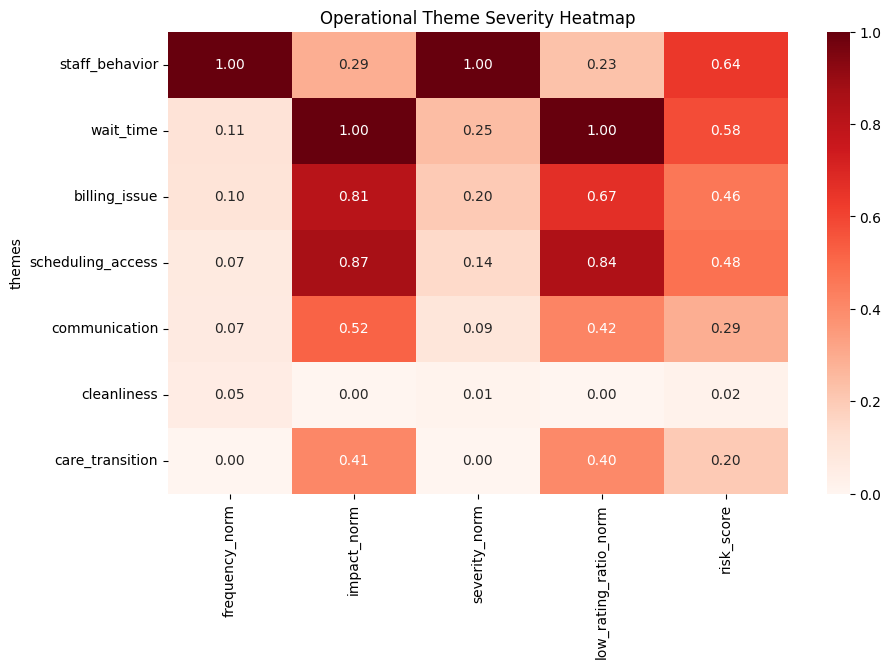

In [ ]:
#heatmap

heatmap_data = theme_stats[[
    "frequency_norm",
    "impact_norm",
    "severity_norm",
    "low_rating_ratio_norm",
    "risk_score"]]

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Operational Theme Severity Heatmap")
plt.show()

In [ ]:
# 1) Priority ranking (no re-definitions)
def priority_level(score):
    if score > 0.5:
        return "High"
    elif score > 0.3:
        return "Medium"
    else:
        return "Low"

theme_stats["priority"] = theme_stats["risk_score"].apply(priority_level)

# 2) Theme -> action map (keys must match your theme labels)
action_map = {
    "wait_time": "Reduce bottlenecks: optimize scheduling, staff to peak hours, and improve patient flow/triage.",
    "staff_behavior": "Improve patient experience: customer service + empathy training, coaching, and accountability standards.",
    "communication": "Standardize communication: scripts/checklists for next steps, timelines, and handoffs.",
    "billing_insurance": "Reduce billing confusion: audit workflow, simplify statements, add pre-visit cost estimates, train staff.",
    "cleanliness": "Increase cleaning frequency/visibility: checklists, audits, and rapid-response for issues.",
    "scheduling_access": "Improve access: online booking, better phone routing, reminders, and availability forecasting.",
    "care_transition": "Improve continuity: standardized discharge instructions, follow-up calls, and coordinated handoffs.",
}

# 3) Auto-generate recommendations (uses your existing theme_stats)
# If your theme labels live in the index instead of a column, handle both cases.
if "themes" in theme_stats.columns:
    theme_stats["recommendation"] = theme_stats["themes"].map(action_map)
else:
    # themes are in the index
    theme_stats["recommendation"] = theme_stats.index.to_series().map(action_map)

theme_stats["recommendation"] = theme_stats["recommendation"].fillna(
    "Investigate root cause (review top examples), then define a standard process + KPI to improve this theme."
)

# 4) Final recommendation table
cols_out = ["priority", "risk_score", "recommendation"]
# add themes if it exists as a column; otherwise we'll keep index
if "themes" in theme_stats.columns:
    cols_out = ["themes"] + cols_out

recommendation_table = (
    theme_stats[cols_out]
      .sort_values(["priority", "risk_score"], ascending=[True, False])
)

recommendation_table

,priority,risk_score,recommendation
themes,,,
staff_behavior,High,0.64,Improve patient experience: customer service +...
wait_time,High,0.58,"Reduce bottlenecks: optimize scheduling, staff..."
communication,Low,0.29,Standardize communication: scripts/checklists ...
care_transition,Low,0.20,Improve continuity: standardized discharge ins...
cleanliness,Low,0.02,Increase cleaning frequency/visibility: checkl...
scheduling_access,Medium,0.48,"Improve access: online booking, better phone r..."
billing_issue,Medium,0.46,"Investigate root cause (review top examples), ..."
